In [ ]:
!pip install ipywidgets


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 11.7 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import ipywidgets as widgets
from IPython.display import display

# Tạo tín hiệu giả lập
x = np.linspace(0, 6 * np.pi, 1000)
y = np.sin(x) + 0.5 * np.sin(3*x) + np.random.normal(0, 0.1, x.size)

# Tạo sliders cho các tham số
height_slider = widgets.FloatSlider(value=0.5, min=0.0, max=2.0, step=0.1, description='Height:')
threshold_slider = widgets.FloatSlider(value=0.0, min=0.0, max=1.0, step=0.05, description='Threshold:')
distance_slider = widgets.IntSlider(value=10, min=1, max=100, step=1, description='Distance:')
prominence_slider = widgets.FloatSlider(value=0.2, min=0.0, max=1.0, step=0.05, description='Prominence:')
width_slider = widgets.FloatSlider(value=1.0, min=0.0, max=10.0, step=0.5, description='Width:')
wlen_slider = widgets.IntSlider(value=-1, min=0, max=1000, step=1, description='Wlen:')
rel_height_slider = widgets.FloatSlider(value=0.5, min=0.0, max=1.0, step=0.1, description='Rel Height:')
plateau_size_slider = widgets.IntSlider(value=1, min=1, max=20, step=1, description='Plateau Size:')

def update_plot(height, threshold, distance, prominence, width, wlen, rel_height, plateau_size):
    plt.figure(figsize=(12, 5))

    if wlen == 0:
      wlen = None

    # Áp dụng find_peaks với các tham số đầu vào từ sliders
    peaks, properties = find_peaks(
        y,
        height=height,
        threshold=threshold,
        distance=distance,
        prominence=prominence,
        width=width,
        wlen=wlen,
        rel_height=rel_height,
        plateau_size=plateau_size
    )

    plt.plot(x, y, label='Signal')
    plt.plot(x[peaks], y[peaks], "x", label='Peaks')
    plt.title("Peak Detection with Adjustable Parameters")
    plt.legend()
    plt.grid(True)
    plt.show()

# Hiển thị interactive widget
ui = widgets.VBox([
    height_slider,
    threshold_slider,
    distance_slider,
    prominence_slider,
    width_slider,
    wlen_slider,
    rel_height_slider,
    plateau_size_slider
])

out = widgets.interactive_output(update_plot, {
    'height': height_slider,
    'threshold': threshold_slider,
    'distance': distance_slider,
    'prominence': prominence_slider,
    'width': width_slider,
    'wlen': wlen_slider,
    'rel_height': rel_height_slider,
    'plateau_size': plateau_size_slider
})

display(ui, out)


Output()

<Figure size 1200x500 with 0 Axes>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# Tạo tín hiệu giả lập
np.random.seed(0)
x = np.linspace(0, 6 * np.pi, 1000)
y = np.sin(x) + 0.5 * np.sin(3*x) + np.random.normal(0, 0.1, x.size)

# Các tham số mặc định để cố định
default_params = {
    'height': None,
    'threshold': None,
    'distance': 10,
    'prominence': 0.2,
    'width': None,
    'wlen': None,
    'rel_height': 0.5,
    'plateau_size': None,
}

def plot_param_effect(param_name, param_values, figsize=(15, 10)):
    rows = (len(param_values) + 2) // 3
    plt.figure(figsize=figsize)

    for i, val in enumerate(param_values):
        params = default_params.copy()
        params[param_name] = val

        # Tìm peaks với tham số thay đổi
        peaks, _ = find_peaks(y, **params)

        plt.subplot(rows, 3, i+1)
        plt.plot(x, y, label="Signal")
        plt.plot(x[peaks], y[peaks], "rx", label="Peaks")
        plt.title(f"{param_name} = {val}")
        plt.grid(True)
        plt.legend()

    plt.suptitle(f"Ảnh hưởng của tham số `{param_name}`", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# Ví dụ cho từng tham số:



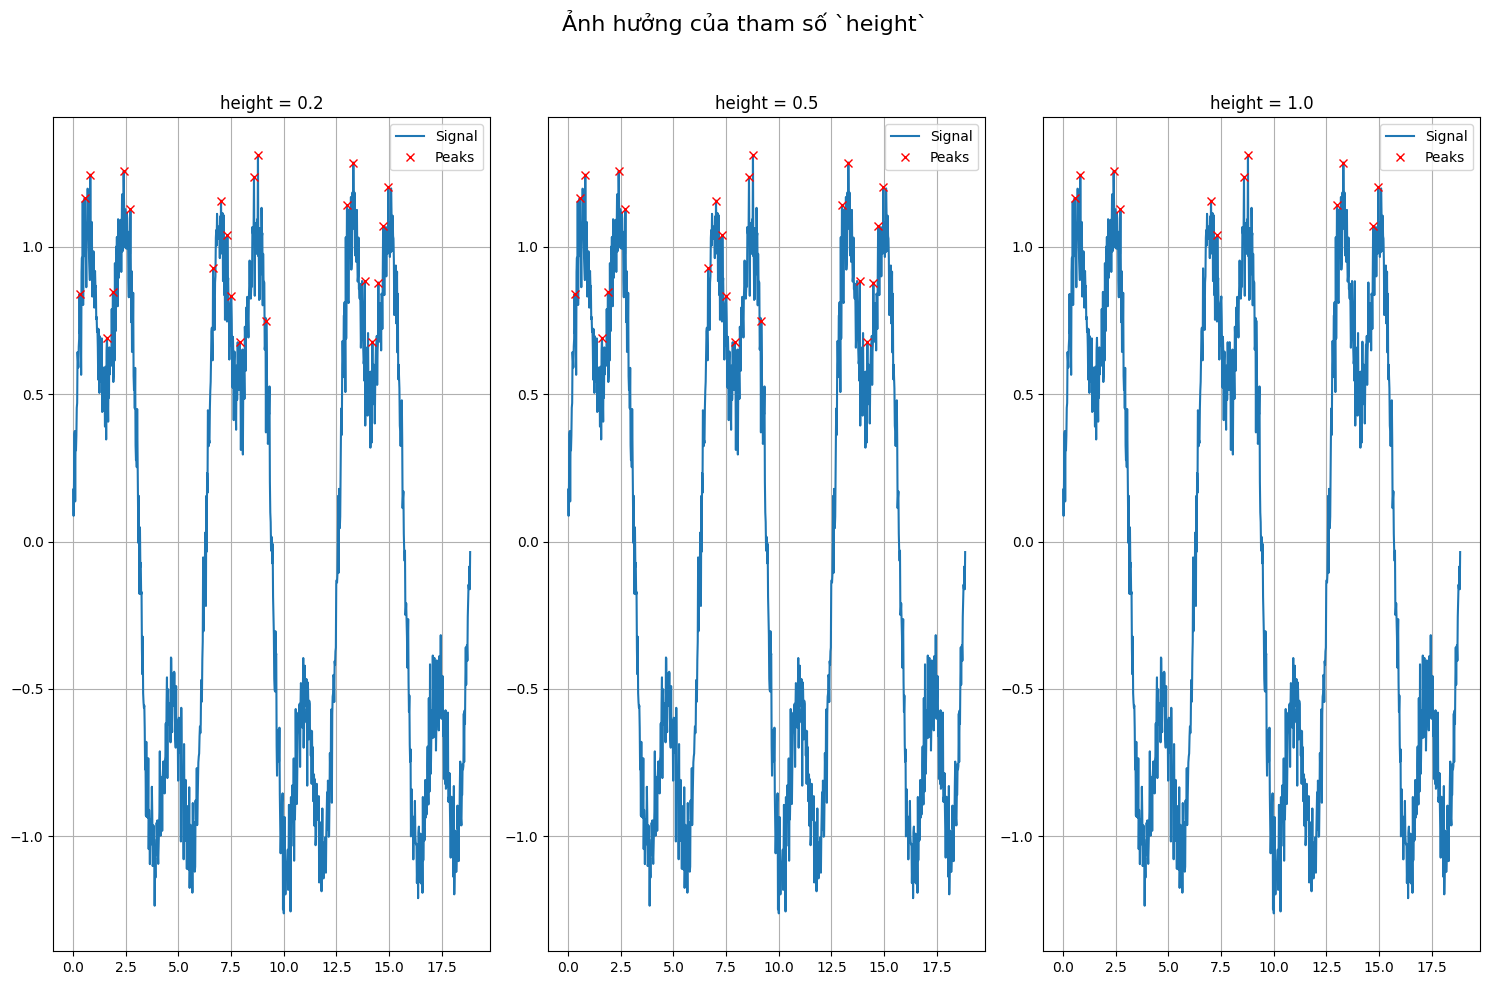

In [ ]:
plot_param_effect('height', [0.2, 0.5, 1.0])



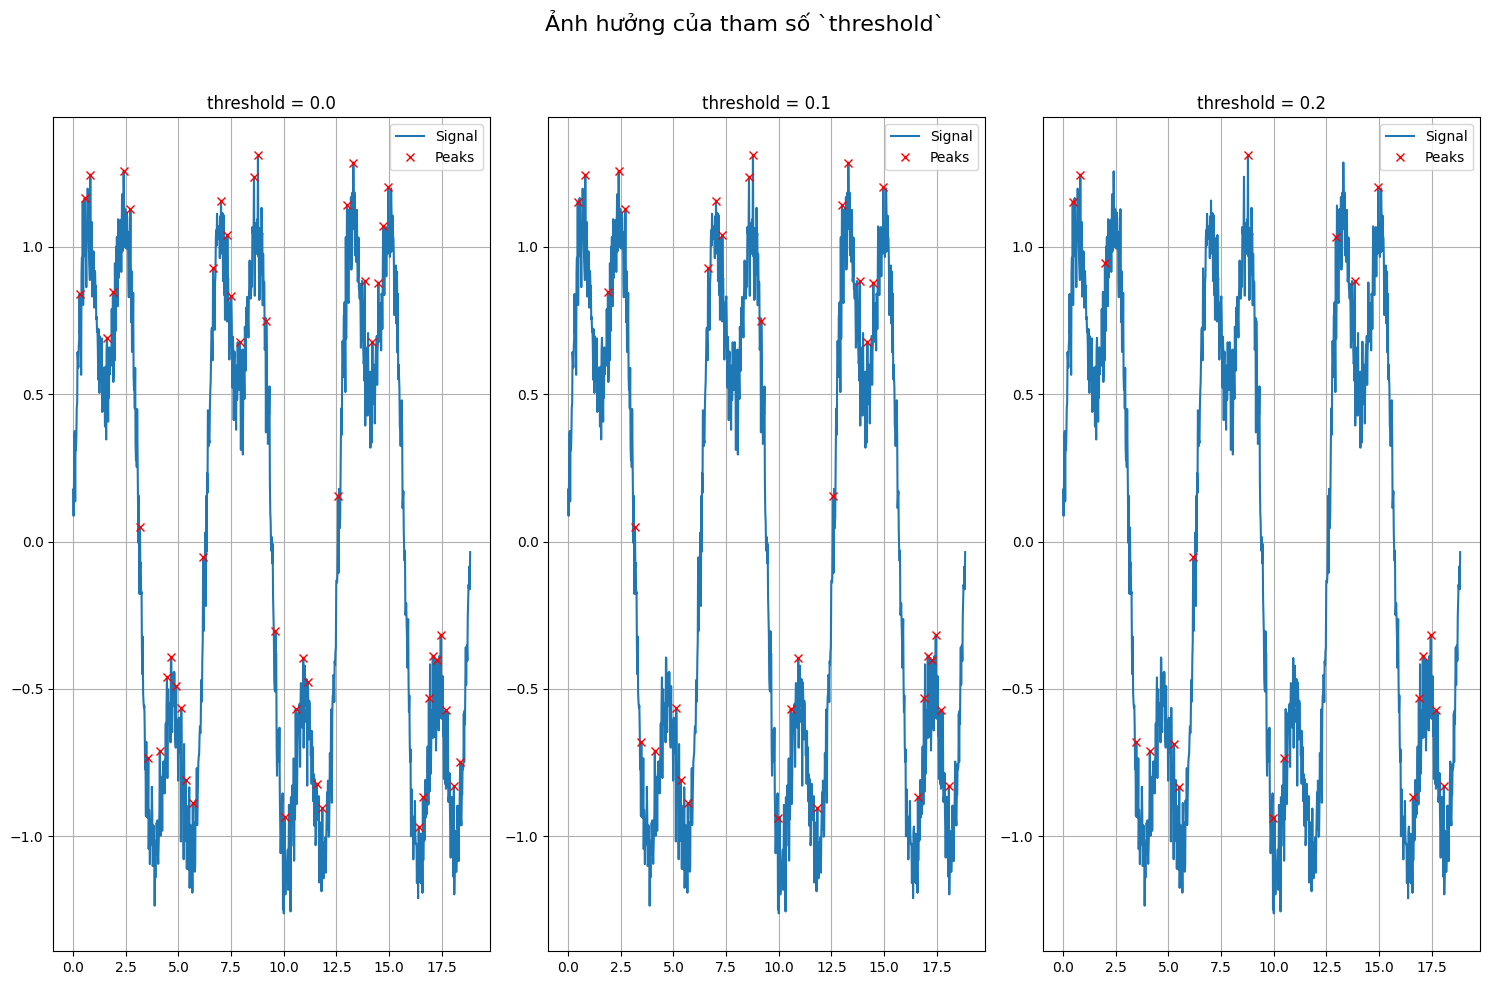

In [ ]:
plot_param_effect('threshold', [0.0, 0.1, 0.2])

In [ ]:
plot_param_effect('distance', [1, 10, 50])
plot_param_effect('prominence', [0.1, 0.3, 0.5])


In [ ]:
plot_param_effect('width', [None, 2, 5])
plot_param_effect('wlen', [None, 50, 200])


In [ ]:
plot_param_effect('rel_height', [0.2, 0.5, 0.9])
plot_param_effect('plateau_size', [None, 5, 10])